# Rasm Substitution Analysis

For each ambiguous dotless Rasm, this notebook shows how each dotting method maps it to dotted letters on the **test set**.

Two tables:
1. **Per-letter F1**: for each (Rasm, dotted target letter, method), the F1 of predicting that dotted letter at positions where the source dotless char is that Rasm.
2. **Invalid mappings ("others")**: per (Rasm, method), counts (and percentages) of times the method predicted a letter that is *not* in the valid mapping set for that Rasm.

**Methods**: best-per-family by lowest avg DOER (LSTM, n-gram, Transformer, CANINE) + 3 LLMs (claude-sonnet-4, gpt-4o, gemini-2.5-flash-preview, all fewshot_8 / default_prompt).

**Ambiguous Rasms** (15): all `ARABIC_RASMS` except `ARABIC_LETTERS_WITHOUT_DOTS` (KAF, LAM, MEEM, HAMZA), matching `constants.is_ambigous_rasm()` and how `restore_dots(..., resolve_ambiguous_rasms_only=True)` behaves during evaluation.

In [1]:
import glob
import json
import os
from collections import defaultdict

import pandas as pd
import pyarabic.araby as araby
from tabulate import tabulate

from tnqeet import constants
from tnqeet import remove_dots


def find_repo_root(start=None):
    """Walk up from `start` until we find tnqeet/dotting_models/."""
    cur = os.path.abspath(start or os.getcwd())
    for _ in range(8):
        if os.path.isdir(os.path.join(cur, "tnqeet", "dotting_models")):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    raise RuntimeError(f"Could not locate repo root from {os.getcwd()}")


REPO_ROOT = find_repo_root()
EVAL_ROOT = os.path.join(REPO_ROOT, "tnqeet", "dotting_models")
DATASET_NAME = "test_dataset"

REPO_ROOT

'/raid_storage/SLURM/home/slurm_majedalshaibani/Projects/tnqeet'

## Rasm → valid dotted letters mapping

Invert `LETTERS_MAPPING` to get the set of valid dotted letters for each Rasm. Filter to the 15 ambiguous Rasms.

In [2]:
RASM_TO_DOTTED = defaultdict(list)
for dotted, rasm in constants.LETTERS_MAPPING.items():
    RASM_TO_DOTTED[rasm].append(dotted)

# 15 ambiguous Rasms (matches constants.is_ambigous_rasm)
AMBIGUOUS_RASMS = [r for r in constants.ARABIC_RASMS if constants.is_ambigous_rasm(r)]
VALID_TARGETS = {r: RASM_TO_DOTTED[r] for r in AMBIGUOUS_RASMS}

RASM_NAMES = {
    constants.ALEF_RASM: "ALEF",
    constants.BAA_RASM: "BAA",
    constants.JEEM_RASM: "JEEM",
    constants.DAL_RASM: "DAL",
    constants.RAA_RASM: "RAA",
    constants.SEEN_RASM: "SEEN",
    constants.SAAD_RASM: "SAAD",
    constants.TAA_RASM: "TAA",
    constants.AIN_RASM: "AIN",
    constants.FAA_RASM: "FAA",
    constants.QAF_RASM: "QAF",
    constants.NOON_RASM: "NOON",
    constants.HAA_RASM: "HAA",
    constants.WAW_RASM: "WAW",
    constants.YAA_RASM: "YAA",
}

for r in AMBIGUOUS_RASMS:
    print(f"{RASM_NAMES[r]:6s}  {r}  -> {VALID_TARGETS[r]}")

ALEF    ا  -> ['ا', 'أ', 'إ', 'آ']
BAA     ٮ  -> ['ب', 'ت', 'ث']
JEEM    ح  -> ['ج', 'ح', 'خ']
DAL     د  -> ['د', 'ذ']
RAA     ر  -> ['ر', 'ز']
SEEN    س  -> ['س', 'ش']
SAAD    ص  -> ['ص', 'ض']
TAA     ط  -> ['ط', 'ظ']
AIN     ع  -> ['ع', 'غ']
FAA     ڡ  -> ['ف']
QAF     ٯ  -> ['ق']
NOON    ں  -> ['ن']
HAA     ه  -> ['ه', 'ة']
WAW     و  -> ['و', 'ؤ']
YAA     ى  -> ['ي', 'ى', 'ئ']


## Select best-per-family by lowest average DOER

Each result file is a list of per-example dicts including `doer`. We pick the file with the lowest average DOER per family.

In [3]:
def load_results(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def avg_doer(results):
    return sum(r["doer"] for r in results) / len(results)

def best_file(pattern):
    candidates = glob.glob(pattern)
    scored = []
    for p in candidates:
        try:
            scored.append((avg_doer(load_results(p)), p))
        except Exception as e:
            print(f"skip {p}: {e}")
    scored.sort()
    return scored

lstm_scored = best_file(os.path.join(EVAL_ROOT, "sequence_labeling", "evaluation_results", DATASET_NAME, "LSTM_layers_*_results.json"))
transformer_scored = best_file(os.path.join(EVAL_ROOT, "transformer", "evaluation_results", DATASET_NAME, "Transformer_layers_*_results.json"))
ngram_scored = best_file(os.path.join(EVAL_ROOT, "ngrams", "evaluation_results", DATASET_NAME, "beam_size_*", "ngrams_*.json"))
canine_scored = best_file(os.path.join(EVAL_ROOT, "canine", "evaluation_results", DATASET_NAME, "CANINE-*.json"))

print("=== LSTM ===")
for s, p in lstm_scored:
    print(f"  {s:.4f}  {os.path.basename(p)}")
print("=== Transformer ===")
for s, p in transformer_scored:
    print(f"  {s:.4f}  {os.path.basename(p)}")
print("=== N-gram ===")
for s, p in ngram_scored:
    rel = os.path.relpath(p, EVAL_ROOT)
    print(f"  {s:.4f}  {rel}")
print("=== CANINE ===")
for s, p in canine_scored:
    print(f"  {s:.4f}  {os.path.basename(p)}")

=== LSTM ===
  0.0181  LSTM_layers_5_results.json
  0.0184  LSTM_layers_6_results.json
  0.0187  LSTM_layers_4_results.json
  0.0198  LSTM_layers_3_results.json
  0.0206  LSTM_layers_2_results.json
  0.0283  LSTM_layers_1_results.json
=== Transformer ===
  0.0155  Transformer_layers_12_results.json
  0.0158  Transformer_layers_9_results.json
  0.0162  Transformer_layers_6_results.json
  0.0191  Transformer_layers_3_results.json
=== N-gram ===
  0.0299  ngrams/evaluation_results/test_dataset/beam_size_60/ngrams_8.json
  0.0314  ngrams/evaluation_results/test_dataset/beam_size_50/ngrams_6.json
  0.0458  ngrams/evaluation_results/test_dataset/beam_size_30/ngrams_4.json
  0.0752  ngrams/evaluation_results/test_dataset/beam_size_15/ngrams_3.json
=== CANINE ===
  0.0172  CANINE-canine-s_results.json
  0.0178  CANINE-canine-c_results.json


In [4]:
def label_lstm(path):
    n = os.path.basename(path).split("_")[2]
    return f"LSTM (L={n})"

def label_transformer(path):
    n = os.path.basename(path).split("_")[2]
    return f"Transformer (L={n})"

def label_ngram(path):
    parts = path.split(os.sep)
    beam = [p for p in parts if p.startswith("beam_size_")][0].replace("beam_size_", "")
    n = os.path.basename(path).replace("ngrams_", "").replace(".json", "")
    return f"N-gram (n={n}, beam={beam})"

def label_canine(path):
    name = os.path.basename(path).replace("_results.json", "")
    return name

LLM_FAMILY_DIR = os.path.join(EVAL_ROOT, "llms", "evaluation_results", DATASET_NAME, "fewshot_8", "default_prompt")
LLM_MODELS = ["claude-sonnet-4", "gpt-4o", "gemini-2.5-flash-preview"]

# LSTM: pinned to 6 layers (user-specified). Others: best-per-family (lowest avg DOER).
lstm_path = os.path.join(
    EVAL_ROOT, "sequence_labeling", "evaluation_results", DATASET_NAME, "LSTM_layers_6_results.json"
)

METHODS = []
METHODS.append((label_lstm(lstm_path), lstm_path))
_, ngram_path = ngram_scored[0]
METHODS.append((label_ngram(ngram_path), ngram_path))
_, transformer_path = transformer_scored[0]
METHODS.append((label_transformer(transformer_path), transformer_path))
_, canine_path = canine_scored[0]
METHODS.append((label_canine(canine_path), canine_path))
for m in LLM_MODELS:
    p = os.path.join(LLM_FAMILY_DIR, f"{m}.json")
    METHODS.append((m, p))

print("Selected methods:")
for name, p in METHODS:
    print(f"  {name:34s}  {os.path.relpath(p, REPO_ROOT)}")

Selected methods:
  LSTM (L=6)                          tnqeet/dotting_models/sequence_labeling/evaluation_results/test_dataset/LSTM_layers_6_results.json
  N-gram (n=8, beam=60)               tnqeet/dotting_models/ngrams/evaluation_results/test_dataset/beam_size_60/ngrams_8.json
  Transformer (L=12)                  tnqeet/dotting_models/transformer/evaluation_results/test_dataset/Transformer_layers_12_results.json
  CANINE-canine-s                     tnqeet/dotting_models/canine/evaluation_results/test_dataset/CANINE-canine-s_results.json
  claude-sonnet-4                     tnqeet/dotting_models/llms/evaluation_results/test_dataset/fewshot_8/default_prompt/claude-sonnet-4.json
  gpt-4o                              tnqeet/dotting_models/llms/evaluation_results/test_dataset/fewshot_8/default_prompt/gpt-4o.json
  gemini-2.5-flash-preview            tnqeet/dotting_models/llms/evaluation_results/test_dataset/fewshot_8/default_prompt/gemini-2.5-flash-preview.json


## Length / alignment diagnostics

Before computing the F1 and substitution tables, look at how well each method's output matches the input length and structure.

Methodology:
- Strip tashkeel from both `original_dotted_text` and `predicted_dotted_text`.
- Compute `diff = len(pred_stripped) - len(orig_stripped)`.

For per-position dotting methods (LSTM, n-gram, Transformer, CANINE), `diff` is always 0 — they can't drop or add letters by construction. For LLMs, `diff` is a direct diagnostic of how much the model **hallucinated or dropped** content.

In [5]:
def length_stats(results):
    """For each example, compute diff = len(pred_stripped) - len(orig_stripped)."""
    diffs = []
    for ex in results:
        orig = ex["original_dotted_text"]
        pred = ex.get("predicted_dotted_text") or ""
        oc = araby.strip_tashkeel(orig)
        pc = araby.strip_tashkeel(pred)
        diffs.append((len(oc), len(pc), len(pc) - len(oc)))
    return diffs


LENGTH_DIFFS = {}
rows = []
headers = [
    "Method", "N", "exact (diff=0)", "|diff|<=2", "|diff|<=10",
    "pred shorter", "pred longer", "mean diff", "median |diff|", "max |diff|",
]
for name, path in METHODS:
    res = load_results(path)
    diffs = length_stats(res)
    LENGTH_DIFFS[name] = (res, diffs)
    abs_diffs = sorted(abs(d) for *_, d in diffs)
    n = len(diffs)
    exact = sum(1 for *_, d in diffs if d == 0)
    le2 = sum(1 for *_, d in diffs if abs(d) <= 2)
    le10 = sum(1 for *_, d in diffs if abs(d) <= 10)
    shorter = sum(1 for *_, d in diffs if d < 0)
    longer = sum(1 for *_, d in diffs if d > 0)
    mean_diff = sum(d for *_, d in diffs) / n
    median_abs = abs_diffs[n // 2]
    max_abs = abs_diffs[-1]
    rows.append([
        name, n, exact, le2, le10, shorter, longer,
        f"{mean_diff:+.2f}", median_abs, max_abs,
    ])

print(tabulate(rows, headers=headers, tablefmt="github", stralign="right"))

|                   Method |    N |   exact (diff=0) |   |diff|<=2 |   |diff|<=10 |   pred shorter |   pred longer |   mean diff |   median |diff| |   max |diff| |
|--------------------------|------|------------------|-------------|--------------|----------------|---------------|-------------|-----------------|--------------|
|               LSTM (L=6) | 5000 |             5000 |        5000 |         5000 |              0 |             0 |        0    |               0 |            0 |
|    N-gram (n=8, beam=60) | 5000 |             5000 |        5000 |         5000 |              0 |             0 |        0    |               0 |            0 |
|       Transformer (L=12) | 5000 |             5000 |        5000 |         5000 |              0 |             0 |        0    |               0 |            0 |
|          CANINE-canine-s | 5000 |             5000 |        5000 |         5000 |              0 |             0 |        0    |               0 |            0 |
|          claud

### LLM hallucination examples

Three examples per LLM, all with non-zero length diff, picked to show the spectrum of severity:

- **little** — smallest non-zero `|diff|` for that model.
- **mid** — median `|diff|` among the non-zero diffs.
- **severe** — largest `|diff|` (worst hallucination / truncation observed).

Both texts are tashkeel-stripped for compact display, and each is shown as a head and tail snippet so divergence is visible.

In [6]:
def snippet(text, head=120, tail=40):
    if len(text) <= head + tail + 5:
        return text
    return f"{text[:head]} … {text[-tail:]}"


def pick_examples(diffs):
    """Return (little, mid, severe) example indices, all with diff != 0."""
    nonzero = sorted(
        [(i, abs(d)) for i, (_, _, d) in enumerate(diffs) if d != 0],
        key=lambda t: t[1],
    )
    if not nonzero:
        return []
    little_idx = nonzero[0][0]
    mid_idx = nonzero[len(nonzero) // 2][0]
    severe_idx = nonzero[-1][0]
    return [("little", little_idx), ("mid", mid_idx), ("severe", severe_idx)]


for name, _ in METHODS:
    if name not in LLM_MODELS:
        continue
    res, diffs = LENGTH_DIFFS[name]
    print("=" * 100)
    print(f"LLM: {name}")
    print("=" * 100)
    for label, idx in pick_examples(diffs):
        ex = res[idx]
        oc = araby.strip_tashkeel(ex["original_dotted_text"])
        pc = araby.strip_tashkeel(ex.get("predicted_dotted_text") or "")
        print(f"\n[{label}]  example #{idx}  orig_len={len(oc)}  pred_len={len(pc)}  diff={len(pc) - len(oc):+d}")
        print(f"  orig: {snippet(oc)}")
        print(f"  pred: {snippet(pc)}")
    print()

LLM: claude-sonnet-4

[little]  example #7  orig_len=3111  pred_len=3110  diff=-1
  orig: "قليلا ما نسمع صوت الصين فيما يخص الشأن السوري، لكن بعد إعلان روسيا عن مبادرتها بشأن تحقيق دولي حول الأسلحة الكيماوية في … ي. إحدى تلك العواقب ارتفاع أسعار النفط."
  pred: "قليلا ما نسمع صوت الصين فيما يخص الشأن السوري، لكن بعد إعلان روسيا عن مبادرتها بشأن تحقيق دولي حول الأسلحة الكيماوية في … ي. إحدى تلك العواقب ارتفاع أسعار النفط."

[mid]  example #3338  orig_len=55  pred_len=57  diff=+2
  orig: ويش رايك في الناس الي تشارك يومياتهم على وسائل التواصل؟
  pred: وإيش رأيك في الناس اللي تشارك يومياتهم على وسائل التواصل؟

[severe]  example #2101  orig_len=6619  pred_len=3801  diff=-2818
  orig: "محاولات فكرية وأكاديمية عديدة خاضها مفكرون وباحثون في خضم مواجهة فكر الحركات الإسلامية، لاسيما ما يتعلق بفك الاشتباك بي … ع الجماهير؟ لماذا بقيت في إطار نخبوي؟"""
  pred: "محاولات فكرية وأكاديمية عديدة خاضها مفكرون وباحثون في خضم مواجهة فكر الحركات الإسلامية، لاسيما ما يتعلق بفك الاشتباك بي … ""المقاصد الشرعية

### |diff| vs sample length

Does longer input drive larger length-divergence? Plot per-example `|diff|` against `orig_len` for the three LLMs. Scatter shows the full distribution at low opacity; the bold line is the binned median (length quantile bins), so the trend is readable through the noise.

`y`-axis is symlog (linear under 10, log above) so small everyday diffs and the multi-thousand outliers both stay visible.

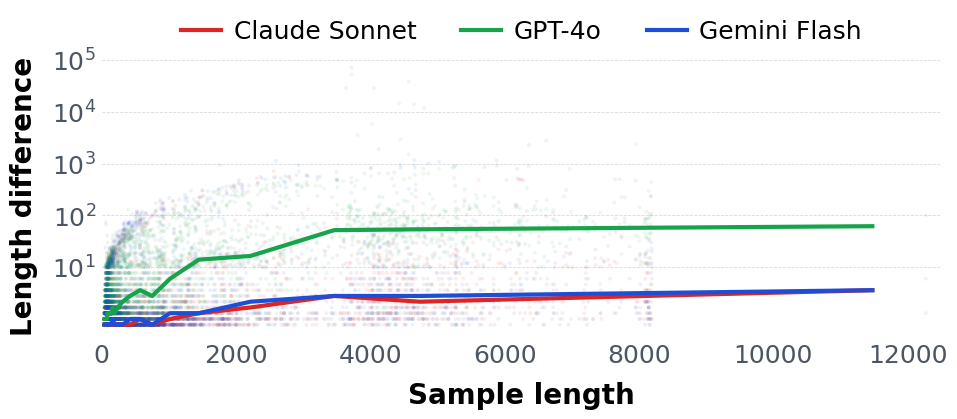

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Helvetica", "Arial"],
    "font.size": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "axes.labelweight": "bold",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

LLM_PALETTE = {
    "claude-sonnet-4": "#DC2626",          # crimson
    "gpt-4o": "#16A34A",                   # green
    "gemini-2.5-flash-preview": "#1D4ED8", # blue
}
MODEL_DISPLAY = {
    "claude-sonnet-4": "Claude Sonnet",
    "gpt-4o": "GPT-4o",
    "gemini-2.5-flash-preview": "Gemini Flash",
}

X_MAX = 12500


def binned_median(x, y, n_bins=20):
    """Median y per quantile bin of x. Returns (bin_centers, medians)."""
    x = np.asarray(x); y = np.asarray(y)
    order = np.argsort(x)
    x, y = x[order], y[order]
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    centers, meds = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (x >= lo) & (x <= hi)
        if mask.sum() >= 5:
            centers.append((lo + hi) / 2)
            meds.append(np.median(y[mask]))
    return np.array(centers), np.array(meds)


fig, ax = plt.subplots(figsize=(10.0, 4.6))
fig.patch.set_facecolor("white")

handles = []
for name in LLM_MODELS:
    _, diffs = LENGTH_DIFFS[name]
    orig_lens = np.array([o for o, _, _ in diffs])
    abs_diffs = np.array([abs(d) for _, _, d in diffs])
    color = LLM_PALETTE[name]
    ax.scatter(orig_lens, abs_diffs, s=8, color=color, alpha=0.08, edgecolors="none")
    cx, cy = binned_median(orig_lens, abs_diffs, n_bins=25)
    (line,) = ax.plot(cx, cy, color=color, linewidth=3.0, label=MODEL_DISPLAY[name])
    handles.append(line)

ax.set_yscale("symlog", linthresh=10)
ax.set_xlim(0, X_MAX)
ax.set_xlabel("Sample length", labelpad=10)
ax.set_ylabel("Length difference", labelpad=10)

# Drop axis spines entirely; rely on subtle grid + tick labels.
for spine in ax.spines.values():
    spine.set_visible(False)

# Hide the y-axis "0" tick — it visually collides with the x-axis "0" in the corner.
ax.set_yticks([t for t in ax.get_yticks() if t != 0])

ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.4, color="#9CA3AF")
ax.set_axisbelow(True)
ax.tick_params(axis="both", which="both", length=0, colors="#4B5563", pad=4)

# Compact legend (no "Median:" prefix — the caption already states the lines are
# binned medians, and the prefix was forcing the legend to overflow the figure width).
ax.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.005),
    ncol=len(handles),
    frameon=False,
    handlelength=1.6,
    handletextpad=0.5,
    columnspacing=1.8,
    borderaxespad=0.0,
)

fig.tight_layout()

FIGURES_DIR = os.path.join(REPO_ROOT, "tnqeet", "notebooks", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
plt.savefig(os.path.join(FIGURES_DIR, "llm_length_diff_vs_sample_length.pdf"), bbox_inches="tight")
plt.show()

## Per-position confusion tally

For each method, walk every example position-by-position:
1. Strip tashkeel from the **full** `original_dotted_text`, `dotless_text`, and `predicted_dotted_text` first — no character-level truncation beforehand.
2. **Length filter** — verify `len(orig_c) == len(dotless_c)` (should always hold since `dotless = remove_dots(orig)`). For pred, require `len(pred_c) >= len(orig_c)`, then truncate `pred_c` to `len(orig_c)` on **letter count**. If pred has fewer non-tashkeel chars than orig, skip the example. (Note: the evaluation script truncates before stripping; we don't, because that bleeds tashkeel-count drift into the boundary and creates spurious length mismatches.)
3. **Alignment filter** — compute the *Rasm-match rate* of the prediction: fraction of positions where `remove_dots(pred_stripped)[i] == dotless_stripped[i]`. Skip the example if this rate is below `ALIGNMENT_THRESHOLD` (default 0.95). This drops examples where an LLM produced a different tashkeel pattern that coincidentally length-matches but shifts the letter alignment by 1+ characters. Examples with isolated invalid-letter predictions (a few %) are retained so their invalid mappings still get counted.
4. At each position where source dotless char is an ambiguous Rasm, record `(rasm, truth, pred)`.

From this tally we build both the F1 table and the invalid-mapping table.

The non-LLM methods (LSTM, n-gram, Transformer, CANINE) predict per-position so they always align — only LLMs see significant skipping.

In [8]:
AMBIGUOUS_SET = set(AMBIGUOUS_RASMS)
VALID_SETS = {r: set(VALID_TARGETS[r]) for r in AMBIGUOUS_RASMS}
ALIGNMENT_THRESHOLD = 0.95


def analyze(results, alignment_threshold=ALIGNMENT_THRESHOLD):
    """Return:
    - tally: dict[rasm][(truth, pred)] -> count
    - rasm_total: dict[rasm] -> total ambiguous-position occurrences
    - invalid_count: dict[rasm] -> # positions where pred not in valid set for that rasm
    - skip_len: # examples skipped because pred has fewer non-tashkeel chars than orig
    - skip_align: # examples skipped because Rasm-match rate < threshold
    """
    tally = defaultdict(lambda: defaultdict(int))
    rasm_total = defaultdict(int)
    invalid_count = defaultdict(int)
    skip_len = 0
    skip_align = 0
    for ex in results:
        orig = ex["original_dotted_text"]
        dotless = ex["dotless_text"]
        pred = ex.get("predicted_dotted_text") or ""
        # Strip tashkeel from full texts first, then truncate on LETTER count.
        orig_c = araby.strip_tashkeel(orig)
        dotless_c = araby.strip_tashkeel(dotless)
        pred_c = araby.strip_tashkeel(pred)
        if len(pred_c) < len(orig_c) or len(orig_c) == 0:
            skip_len += 1
            continue
        pred_c = pred_c[: len(orig_c)]
        pred_rasm = remove_dots(pred_c)
        matches = sum(1 for a, b in zip(pred_rasm, dotless_c) if a == b)
        if matches / len(dotless_c) < alignment_threshold:
            skip_align += 1
            continue
        for i, src in enumerate(dotless_c):
            if src not in AMBIGUOUS_SET:
                continue
            truth = orig_c[i]
            p = pred_c[i]
            rasm_total[src] += 1
            tally[src][(truth, p)] += 1
            if p not in VALID_SETS[src]:
                invalid_count[src] += 1
    return tally, rasm_total, invalid_count, skip_len, skip_align


ANALYSES = {}
for name, path in METHODS:
    res = load_results(path)
    ANALYSES[name] = analyze(res)
    _, _, _, skl, ska = ANALYSES[name]
    print(f"{name:34s}  examples={len(res):5d}  skip_len={skl:5d}  skip_align={ska:5d}  used={len(res) - skl - ska}")

LSTM (L=6)                          examples= 5000  skip_len=    0  skip_align=    0  used=5000
N-gram (n=8, beam=60)               examples= 5000  skip_len=    0  skip_align=    0  used=5000
Transformer (L=12)                  examples= 5000  skip_len=    0  skip_align=    0  used=5000
CANINE-canine-s                     examples= 5000  skip_len=    0  skip_align=    0  used=5000
claude-sonnet-4                     examples= 5000  skip_len= 1191  skip_align= 1549  used=2260
gpt-4o                              examples= 5000  skip_len= 2970  skip_align= 1641  used=389
gemini-2.5-flash-preview            examples= 5000  skip_len= 1594  skip_align= 1220  used=2186


## Table 1: Per-letter F1

For each (Rasm, target letter), F1 is computed within positions where source dotless char is that Rasm:

- **TP** = # positions where truth = target and pred = target
- **FP** = # positions where truth ≠ target and pred = target
- **FN** = # positions where truth = target and pred ≠ target
- **F1** = 2·TP / (2·TP + FP + FN); 0.0 when denominator is 0.

In [9]:
def f1_for(tally_rasm, target):
    tp = fp = fn = 0
    for (truth, pred), c in tally_rasm.items():
        if pred == target and truth == target:
            tp += c
        elif pred == target and truth != target:
            fp += c
        elif pred != target and truth == target:
            fn += c
    denom = 2 * tp + fp + fn
    return 0.0 if denom == 0 else (2 * tp) / denom

rows = []
headers = ["Rasm", "Target"] + [name for name, _ in METHODS]
for rasm in AMBIGUOUS_RASMS:
    for j, target in enumerate(VALID_TARGETS[rasm]):
        row = [f"{RASM_NAMES[rasm]} ({rasm})" if j == 0 else "", target]
        for name, _ in METHODS:
            tally, *_ = ANALYSES[name]
            f1 = f1_for(tally[rasm], target)
            row.append(f"{f1 * 100:6.2f}")
        rows.append(row)

f1_df = pd.DataFrame(rows, columns=headers)
print(tabulate(rows, headers=headers, tablefmt="github", stralign="center"))

|   Rasm   |  Target  |   LSTM (L=6) |   N-gram (n=8, beam=60) |   Transformer (L=12) |   CANINE-canine-s |   claude-sonnet-4 |   gpt-4o |   gemini-2.5-flash-preview |
|----------|----------|--------------|-------------------------|----------------------|-------------------|-------------------|----------|----------------------------|
| ALEF (ا) |    ا     |        98.26 |                   97.29 |                98.03 |             98.22 |             98.33 |    95.43 |                      97.51 |
|          |    أ     |        91.2  |                   86.26 |                90.46 |             91.35 |             89.63 |    89.89 |                      84.89 |
|          |    إ     |        87.52 |                   80.07 |                85.02 |             87.73 |             88.41 |    88.73 |                      87.05 |
|          |    آ     |        83.12 |                   62.51 |                83.76 |             84.2  |             89.27 |    88.14 |                      

## Save tables to CSV (optional)

In [10]:
# OUT_DIR = os.path.join(REPO_ROOT, "tnqeet", "notebooks", "figures")
# os.makedirs(OUT_DIR, exist_ok=True)
# f1_df.to_csv(os.path.join(OUT_DIR, "rasm_substitution_f1.csv"), index=False)
# invalid_counts_df.to_csv(os.path.join(OUT_DIR, "rasm_invalid_mappings_counts.csv"), index=False)
# invalid_pct_df.to_csv(os.path.join(OUT_DIR, "rasm_invalid_mappings_pct.csv"), index=False)
# print("saved to", OUT_DIR)